Single Neural Network Architecture- Back Propagation

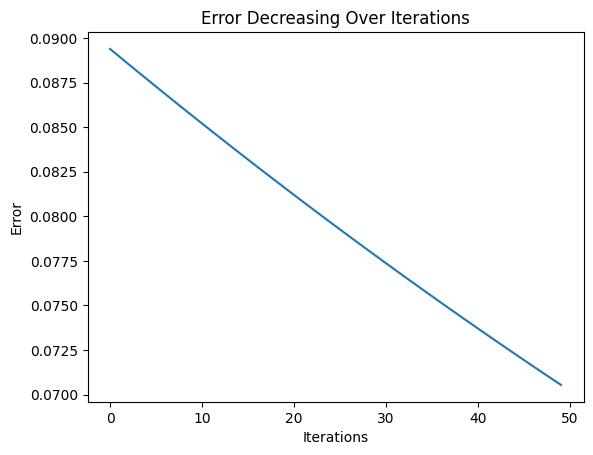

In [ ]:
import math
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + math.exp(-x))

# Derivative
def sigmoid_derivative(x):
    return x * (1 - x)

# Given values
x = 1
target = 1

w1 = 0.5
w2 = 0.5

learning_rate = 0.1

errors = []
iterations = 50

# Training loop
for i in range(iterations):

    # Forward pass
    z1 = w1 * x
    h = sigmoid(z1)

    z2 = w2 * h
    y = sigmoid(z2)

    # Error
    error = 0.5 * (target - y) ** 2
    errors.append(error)

    # Backpropagation
    dE_dy = (y - target)
    dy_dz2 = sigmoid_derivative(y)

    dE_dw2 = dE_dy * dy_dz2 * h

    dz2_dh = w2
    dh_dz1 = sigmoid_derivative(h)

    dE_dw1 = dE_dy * dy_dz2 * dz2_dh * dh_dz1 * x

    # Update weights
    w2 = w2 - learning_rate * dE_dw2
    w1 = w1 - learning_rate * dE_dw1

# Plot graph
plt.plot(range(iterations), errors)
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.title("Error Decreasing Over Iterations")
plt.show()


Back Propagation - Neural Network Architecture

In [ ]:
import numpy as np

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid
def sigmoid_derivative(x):
    return x * (1 - x)

# XOR dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# Initialize weights
np.random.seed(42)
w1 = np.random.rand(2, 2)   # input → hidden
w2 = np.random.rand(2, 1)   # hidden → output

learning_rate = 0.5
epochs = 10000

# Training
for i in range(epochs):

    # Forward propagation
    hidden = sigmoid(np.dot(X, w1))
    output = sigmoid(np.dot(hidden, w2))

    # Error
    error = y - output

    # Backpropagation
    d_output = error * sigmoid_derivative(output)
    d_hidden = d_output.dot(w2.T) * sigmoid_derivative(hidden)

    # Update weights
    w2 += hidden.T.dot(d_output) * learning_rate
    w1 += X.T.dot(d_hidden) * learning_rate

# Final Output
print("Predicted Output after training:\n", output)

Predicted Output after training:
 [[0.05432736]
 [0.89823995]
 [0.89824011]
 [0.13514441]]


In [ ]:
#PROBLEM STATEMENT:
#
# Design and train a Multi-Layer Perceptron (MLP) using
# backpropagation to learn the XOR logic function.
#
# Given Dataset:
# Input (x1, x2) → Output (y)
# (0, 0) → 0
# (0, 1) → 1
# (1, 0) → 1
# (1, 1) → 0
#
# Network Architecture:
# - Input Layer: 2 neurons
# - Hidden Layer: 2 neurons
# - Output Layer: 1 neuron
#
# Conditions:
# - Use Sigmoid activation function
# - Use Backpropagation for training
# - Initialize weights randomly
# - Train for multiple epochs to minimize error
#
# Objective:
# Train the network such that it correctly predicts XOR outputs.
# ============================================================

import numpy as np

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid
def sigmoid_derivative(x):
    return x * (1 - x)

# Input dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Target output
y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# Set seed for reproducibility
np.random.seed(42)

# Initialize weights
w1 = np.random.rand(2, 2)  # input → hidden
w2 = np.random.rand(2, 1)  # hidden → output

learning_rate = 0.5
epochs = 10000

# Training loop
for epoch in range(epochs):

    # Forward Propagation
    hidden_input = np.dot(X, w1)
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, w2)
    final_output = sigmoid(final_input)

    # Error calculation
    error = y - final_output

    # Backpropagation
    d_output = error * sigmoid_derivative(final_output)

    hidden_error = d_output.dot(w2.T)
    d_hidden = hidden_error * sigmoid_derivative(hidden_output)

    # Update weights
    w2 += hidden_output.T.dot(d_output) * learning_rate
    w1 += X.T.dot(d_hidden) * learning_rate

# Final output
print("Final Output after training:\n")
print(final_output)

Final Output after training:

[[0.05432736]
 [0.89823995]
 [0.89824011]
 [0.13514441]]


Multi Layer Perceptron: ML & Deeep Learning

In [ ]:
import numpy as np
# XOR Gate
# Input dataset (XOR)
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

# Output dataset
y = np.array([[0],
              [1],
              [1],
              [0]])

# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid
def sigmoid_derivative(x):
    return x * (1 - x)

# Initialize weights randomly
np.random.seed(42)

input_neurons = 2
hidden_neurons = 4
output_neurons = 1

# Weights and bias
W1 = np.random.uniform(size=(input_neurons, hidden_neurons))
b1 = np.random.uniform(size=(1, hidden_neurons))

W2 = np.random.uniform(size=(hidden_neurons, output_neurons))
b2 = np.random.uniform(size=(1, output_neurons))

# Training
epochs = 10000
lr = 0.1

for i in range(epochs):

    # Forward Propagation
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2) + b2
    predicted_output = sigmoid(final_input)

    # Error
    error = y - predicted_output

    # Backpropagation
    d_output = error * sigmoid_derivative(predicted_output)

    error_hidden = d_output.dot(W2.T)
    d_hidden = error_hidden * sigmoid_derivative(hidden_output)

    # Update weights and bias
    W2 += hidden_output.T.dot(d_output) * lr
    b2 += np.sum(d_output, axis=0, keepdims=True) * lr

    W1 += X.T.dot(d_hidden) * lr
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

# Final Output
print("Predicted Output:")
print(predicted_output)

Predicted Output:
[[0.04690963]
 [0.95663392]
 [0.92548675]
 [0.07177571]]


In [ ]:
import numpy as np
# AND Gate
# Input dataset (AND)
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

# Output dataset
y = np.array([[0],
              [0],
              [0],
              [1]])

# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid
def sigmoid_derivative(x):
    return x * (1 - x)

# Initialize weights randomly
np.random.seed(42)

input_neurons = 2
hidden_neurons = 4
output_neurons = 1

# Weights and bias
W1 = np.random.uniform(size=(input_neurons, hidden_neurons))
b1 = np.random.uniform(size=(1, hidden_neurons))

W2 = np.random.uniform(size=(hidden_neurons, output_neurons))
b2 = np.random.uniform(size=(1, output_neurons))

# Training
epochs = 10000
lr = 0.1

for i in range(epochs):

    # Forward Propagation
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2) + b2
    predicted_output = sigmoid(final_input)

    # Error
    error = y - predicted_output

    # Backpropagation
    d_output = error * sigmoid_derivative(predicted_output)

    error_hidden = d_output.dot(W2.T)
    d_hidden = error_hidden * sigmoid_derivative(hidden_output)

    # Update weights and bias
    W2 += hidden_output.T.dot(d_output) * lr
    b2 += np.sum(d_output, axis=0, keepdims=True) * lr

    W1 += X.T.dot(d_hidden) * lr
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

# Final Output
print("Predicted Output:")
print(predicted_output)

Predicted Output:
[[0.00386347]
 [0.03046885]
 [0.03075947]
 [0.96048282]]


AND Gate (Perceptron with Error Plot)

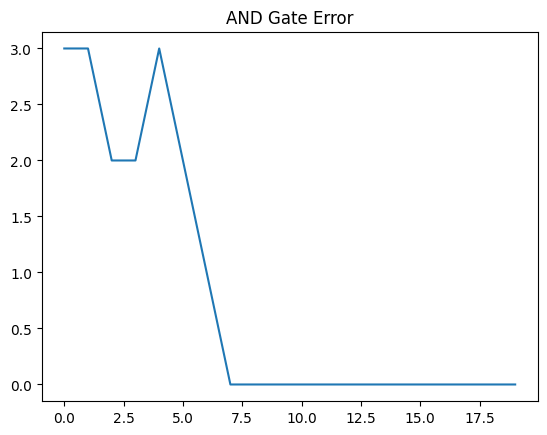

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[0],[0],[1]])

W = np.random.rand(2,1)
b = np.random.rand(1)

def step(x): return 1 if x>=0 else 0

losses = []

for epoch in range(20):
    total_error = 0
    for i in range(4):
        z = np.dot(X[i],W)+b
        pred = step(z)
        error = y[i] - pred
        total_error += error**2
        W += error * X[i].reshape(2,1)
        b += error
    losses.append(total_error)

plt.plot(losses)
plt.title("AND Gate Error")
plt.show()

DIGIT Classification using Multi Layer Perceptron

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

Accuracy: 0.9694444444444444
Actual: 6
Predicted: [6]


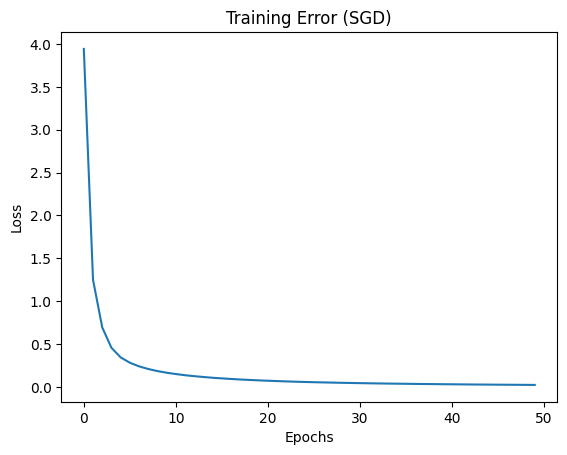

In [ ]:
# Import libraries
from sklearn.datasets import load_digits              # Load digit dataset
from sklearn.model_selection import train_test_split  # Split data
from sklearn.neural_network import MLPClassifier      # MLP model
from sklearn.metrics import accuracy_score            # Accuracy check
import matplotlib.pyplot as plt                       # Plot error

# Load dataset
digits = load_digits()

# Input (pixel values) and Output (labels 0–9)
X = digits.data
y = digits.target

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create MLP model using SGD
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # Two hidden layers
    activation='relu',            # Activation function
    solver='sgd',                 # SGD optimizer (no Adam)
    learning_rate_init=0.01,      # Learning rate
    max_iter=1,                   # Train 1 epoch at a time
    warm_start=True,              # Continue training
    random_state=42
)

# Store loss values
losses = []

# Train model for multiple epochs manually
for epoch in range(50):
    model.fit(X_train, y_train)     # Train one epoch
    losses.append(model.loss_)      # Store error (loss)

# Predict on test data
y_pred = model.predict(X_test)

# Print accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Example prediction
print("Actual:", y_test[0])
print("Predicted:", model.predict([X_test[0]]))

# Plot error curve
plt.plot(losses)
plt.title("Training Error (SGD)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

DISPLAY GRAPH:

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

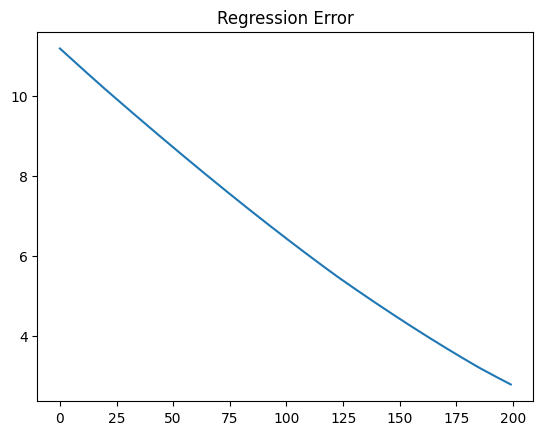

In [ ]:
# Import MLPRegressor (Neural Network for regression)
from sklearn.neural_network import MLPRegressor

# Import numpy for handling arrays
import numpy as np

# Import matplotlib to plot graph
import matplotlib.pyplot as plt


# Input data (features)
# 4 samples, each with 1 feature
X = np.array([[1],[2],[3],[4]])

# Output data (target values)
# Relationship: y = 2 * X
y = np.array([2,4,6,8])


# Create MLP model
model = MLPRegressor(
    hidden_layer_sizes=(5,),  # One hidden layer with 5 neurons
    max_iter=1,               # Train only 1 iteration at a time
    warm_start=True           # Continue training from previous state
)


# List to store loss (error) values
losses = []


# Train model for 200 epochs manually
for i in range(200):

    model.fit(X, y)          # Train model on data (one iteration only)

    losses.append(model.loss_)  # Store current loss after training


# Plot error curve (loss vs epochs)
plt.plot(losses)

# Title of graph
plt.title("Regression Error")

# Display graph
plt.show()


DEEP LEARNING ALGORITHM:

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.K5B2QO_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 77s 130ms/step - accuracy: 0.5688 - loss: 0.6814 - val_accuracy: 0.6195 - val_loss: 0.6658
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 70s 121ms/step - accuracy: 0.6098 - loss: 0.6571 - val_accuracy: 0.6423 - val_loss: 0.6393
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 77s 131ms/step - accuracy: 0.6377 - loss: 0.6350 - val_accuracy: 0.6649 - val_loss: 0.6195
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.6612 - loss: 0.6132 - val_accuracy: 0.6829 - val_loss: 0.5988
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 71s 122ms/step - accuracy: 0.6852 - loss: 0.5891 - val_accuracy: 0.7021 - val_loss: 0.5768


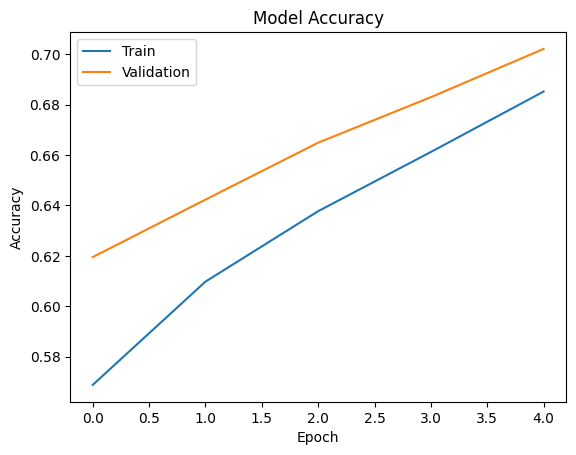

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Prediction: Dog 🐶


In [ ]:
# Step 1: Import required libraries
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Step 2: Load dataset correctly (FIXED)
train_data, val_data = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],   # 80% training, 20% validation
    as_supervised=True                      # returns (image, label)
)

# Step 3: Preprocess images (resize + normalize)
def preprocess(image, label):
    image = tf.image.resize(image, (64, 64))  # Resize image
    image = image / 255.0                     # Normalize (0–1)
    return image, label

train_data = train_data.map(preprocess).batch(32)
val_data = val_data.map(preprocess).batch(32)

# Step 4: Build CNN model
model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')   # Binary output (cat/dog)
])

# Step 5: Compile model
model.compile(
    optimizer='sgd',                        # Using SGD (as you requested)
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Step 6: Train model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

# Step 7: Plot accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

# Step 8: Test prediction on one image
for images, labels in val_data.take(1):
    sample_image = images[0]
    break

# Expand dimensions for prediction
sample_image = tf.expand_dims(sample_image, axis=0)

prediction = model.predict(sample_image)

# Step 9: Output result
if prediction[0][0] > 0.5:
    print("Prediction: Dog 🐶")
else:
    print("Prediction: Cat 🐱")

Principal Component Analysis

ORIGINAL DATASET
   Math  Physics  Chemistry
A    80       82         81
B    70       72         71
C    90       88         89
D    60       62         61
E    85       84         86
F    75       78         76

STANDARDIZED DATA
       Math   Physics  Chemistry
A  0.338062  0.504118   0.388909
B -0.676123 -0.659232  -0.671751
C  1.352247  1.202128   1.237437
D -1.690309 -1.822582  -1.732412
E  0.845154  0.736788   0.919239
F -0.169031  0.038778  -0.141421

PCA TRANSFORMED DATA
        PC1       PC2
A  0.710659  0.120025
B -1.158815  0.011206
C  2.189252 -0.086426
D -3.028288 -0.097614
E  1.444206 -0.106427
F -0.157014  0.159236

EXPLAINED VARIANCE RATIO
PC1: 0.9956
PC2: 0.0038

Total Variance Retained: 99.94 %

PRINCIPAL COMPONENT VECTORS
         Math   Physics  Chemistry
PC1  0.577515  0.576467   0.578067
PC2 -0.523895  0.804749  -0.279128


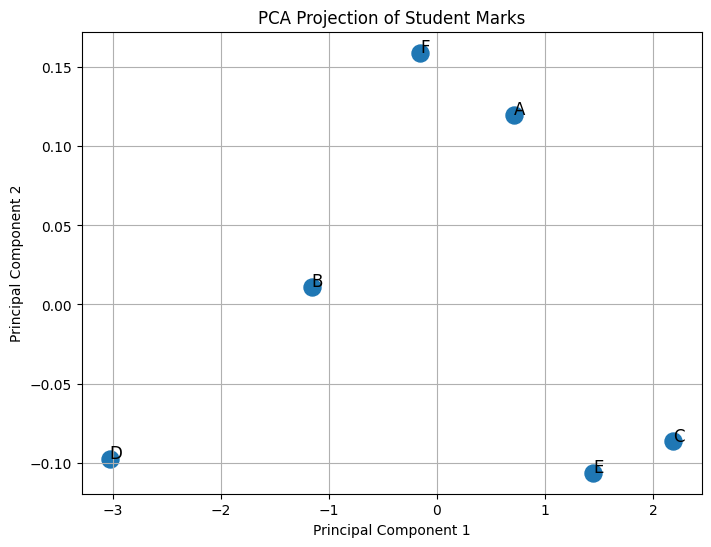

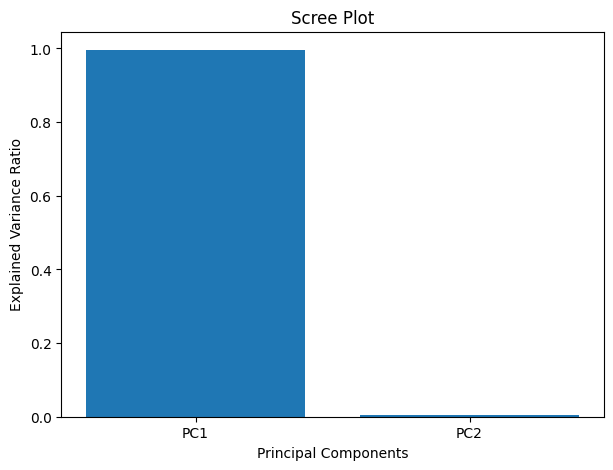

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -----------------------------------------------------
# Step 1: Create Dataset
# -----------------------------------------------------

data = {
    'Math': [80, 70, 90, 60, 85, 75],
    'Physics': [82, 72, 88, 62, 84, 78],
    'Chemistry': [81, 71, 89, 61, 86, 76]
}

students = ['A', 'B', 'C', 'D', 'E', 'F']

df = pd.DataFrame(data, index=students)

print("================================")
print("ORIGINAL DATASET")
print("================================")
print(df)

# -----------------------------------------------------
# Step 2: Standardization
# -----------------------------------------------------

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

print("\n================================")
print("STANDARDIZED DATA")
print("================================")
print(pd.DataFrame(scaled_data,
                   columns=df.columns,
                   index=students))

# -----------------------------------------------------
# Step 3: Apply PCA
# -----------------------------------------------------

pca = PCA(n_components=2)

principal_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    principal_components,
    columns=['PC1', 'PC2'],
    index=students
)

# -----------------------------------------------------
# Step 4: Display PCA Results
# -----------------------------------------------------

print("\n================================")
print("PCA TRANSFORMED DATA")
print("================================")
print(pca_df)

# -----------------------------------------------------
# Step 5: Explained Variance
# -----------------------------------------------------

print("\n================================")
print("EXPLAINED VARIANCE RATIO")
print("================================")

for i, variance in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {variance:.4f}")

print("\nTotal Variance Retained:",
      round(sum(pca.explained_variance_ratio_)*100, 2), "%")

# -----------------------------------------------------
# Step 6: Principal Component Directions
# -----------------------------------------------------

print("\n================================")
print("PRINCIPAL COMPONENT VECTORS")
print("================================")

pc_vectors = pd.DataFrame(
    pca.components_,
    columns=df.columns,
    index=['PC1', 'PC2']
)

print(pc_vectors)

# -----------------------------------------------------
# Step 7: Visualization
# -----------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    s=150
)

for student in students:
    plt.annotate(
        student,
        (pca_df.loc[student,'PC1'],
         pca_df.loc[student,'PC2']),
        fontsize=12
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Student Marks')
plt.grid(True)

plt.show()

# -----------------------------------------------------
# Step 8: Scree Plot
# -----------------------------------------------------

plt.figure(figsize=(7,5))

explained_variance = pca.explained_variance_ratio_

plt.bar(
    ['PC1', 'PC2'],
    explained_variance
)

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Scree Plot')

plt.show()

Momentum Gradient Descent

In [ ]:
#Momentum Gradient Descent Example
# Objective Function: J(w) = w^2

# Hyperparameters
learning_rate = 0.1
momentum = 0.9

# Initial values
w = 4.0
v = 0.0

# Number of iterations
epochs = 10

print("Iteration\tWeight\t\tGradient\tVelocity")

for i in range(epochs):
    # Gradient of J(w) = w^2
    gradient = 2 * w

    # Update velocity
    v = momentum * v - learning_rate * gradient

    # Update weight
    w = w + v

    print(f"{i+1}\t\t{w:.4f}\t\t{gradient:.4f}\t\t{v:.4f}")

print("\nFinal Weight:", round(w, 4))

Iteration	Weight		Gradient	Velocity
1		3.2000		8.0000		-0.8000
2		1.8400		6.4000		-1.3600
3		0.2480		3.6800		-1.5920
4		-1.2344		0.4960		-1.4824
5		-2.3217		-2.4688		-1.0873
6		-2.8359		-4.6434		-0.5142
7		-2.7315		-5.6718		0.1044
8		-2.0913		-5.4630		0.6402
9		-1.0968		-4.1825		0.9945
10		0.0176		-2.1936		1.1144

Final Weight: 0.0176


CNN Neural Network

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.4434 - loss: 1.5657
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.5655 - loss: 1.2371
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


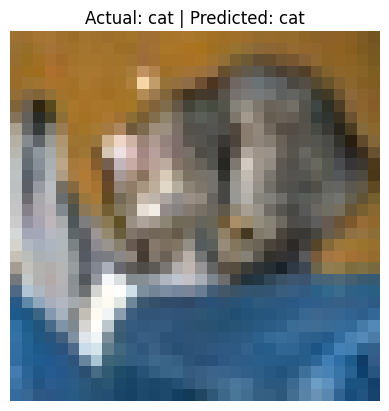

INPUT: Image from CIFAR-10 dataset
ACTUAL OUTPUT: cat
PREDICTED OUTPUT: cat


In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# =========================
# 2. LOAD DATASET (NO FILE ERROR)
# =========================
# CIFAR-10 dataset (contains 60,000 images)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize images (0-255 → 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert labels to categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# =========================
# 3. BUILD CNN MODEL
# =========================
model = Sequential()

# Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))

# Pooling Layer
model.add(MaxPooling2D((2,2)))

# Flatten layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(64, activation='relu'))

# Output Layer (10 classes)
model.add(Dense(10, activation='softmax'))

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# =========================
# 4. TRAIN MODEL
# =========================
model.fit(x_train, y_train, epochs=2, batch_size=64)

# =========================
# 5. TEST WITH ONE IMAGE
# =========================
test_image = x_test[0]   # predefined image
test_label = np.argmax(y_test[0])

# Expand dimensions for prediction
test_image_expanded = np.expand_dims(test_image, axis=0)

# Prediction
prediction = model.predict(test_image_expanded)
predicted_class = np.argmax(prediction)

# =========================
# 6. DISPLAY INPUT & OUTPUT
# =========================
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.imshow(test_image)
plt.title(f"Actual: {class_names[test_label]} | Predicted: {class_names[predicted_class]}")
plt.axis('off')
plt.show()

# =========================
# 7. PRINT OUTPUT
# =========================
print("INPUT: Image from CIFAR-10 dataset")
print("ACTUAL OUTPUT:", class_names[test_label])
print("PREDICTED OUTPUT:", class_names[predicted_class])

Feed Forward Neural Network

In [ ]:
import numpy as np                              # For numerical operations
from tensorflow.keras.models import Sequential  # To create neural network model
from tensorflow.keras.layers import Dense       # Fully connected (feedforward) layer

# =========================
# 2. DEFINE INPUT AND OUTPUT DATA
# =========================

# Input dataset (4 samples, 2 features each)
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

# Output dataset (Expected results of AND logic)
Y = np.array([[0],
              [0],
              [0],
              [1]])

# =========================
# 3. BUILD FEEDFORWARD NEURAL NETWORK MODEL
# =========================

model = Sequential()
# Sequential model = layers arranged one after another (feedforward)

# Add Hidden Layer
model.add(Dense(
    units=3,                # Number of neurons in hidden layer
    input_dim=2,            # Input features (2 inputs)
    activation='relu'       # Activation function (introduces non-linearity)
))

# Add Output Layer
model.add(Dense(
    units=1,                # Single output neuron
    activation='sigmoid'    # Sigmoid for binary output (0 or 1)
))

# =========================
# 4. COMPILE THE MODEL
# =========================

model.compile(
    optimizer='adam',           # Optimizer to adjust weights
    loss='binary_crossentropy', # Loss function for binary classification
    metrics=['accuracy']        # Measure model performance
)

# =========================
# 5. TRAIN THE MODEL
# =========================

model.fit(
    X, Y,            # Training data
    epochs=500,      # Number of iterations
    verbose=0        # 0 = silent training (no logs)
)

# =========================
# 6. MAKE PREDICTIONS
# =========================

predictions = model.predict(X)   # Predict output for all inputs

# =========================
# 7. DISPLAY RESULTS
# =========================

print("=================================")
print("INPUT:")
print(X)

print("\nEXPECTED OUTPUT:")
print(Y)

print("\nPREDICTED OUTPUT (Rounded):")
print(np.round(predictions))  # Round values (e.g., 0.98 → 1)

print("=================================")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
INPUT:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

EXPECTED OUTPUT:
[[0]
 [0]
 [0]
 [1]]

PREDICTED OUTPUT (Rounded):
[[0.]
 [0.]
 [0.]
 [1.]]


IRIS

In [ ]:
import kagglehub
path = kagglehub.dataset_download("gpreda/iris-dataset")

IRIS DATASET ADDED

In [ ]:
import pandas as pd

filepath = "/content/Iris.xlsx"

iris = pd.read_excel(filepath)

print(iris.head()) # head() means first five rows

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


Normalization - MIN MAX Normalization

In [8]:
import pandas as pd

# Load dataset
filepath = "/content/Iris.xlsx"
iris = pd.read_excel(filepath)

print("Original Dataset:")
print(iris.head()) # head() means first five rows

# Select only numerical columns
numeric_columns = iris.select_dtypes(include=['number']).columns

# Min-Max Normalization (0 to 1)
iris_normalized = iris.copy()

iris_normalized[numeric_columns] = (
    iris[numeric_columns] - iris[numeric_columns].min()
) / (
    iris[numeric_columns].max() - iris[numeric_columns].min()
)

print("\nNormalized Dataset (0 to 1):")
print(iris_normalized.head())

Original Dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Normalized Dataset (0 to 1):
         Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0  0.000000       0.222222      0.625000       0.067797      0.041667   
1  0.006711       0.166667      0.416667       0.067797      0.041667   
2  0.013423       0.111111      0.500000       0.050847      0.041667   
3  0.020134       0.083333      0.458333       0.084746      0.041667   
4  0.026846       0.194444      0.666667       0.067797      0.041667   

       Species  
0  Iris-setosa  
1  Iris-setosa  


Principal Component Analysis

PCA Data (3 Columns):
        PC1       PC2       PC3
0 -0.796395  0.127941 -0.085305
1 -0.785587 -0.078706 -0.140089
2 -0.822350 -0.035244 -0.068901
3 -0.805397 -0.085309 -0.078126
4 -0.798588  0.145620 -0.035605

Explained Variance Ratio:
[0.84094005 0.09198147 0.04225984]


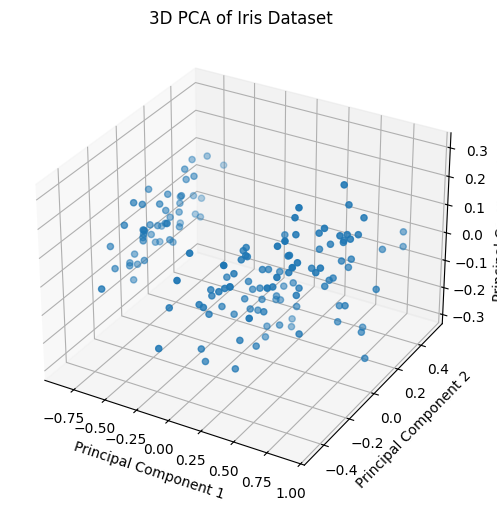

In [9]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load dataset
filepath = "/content/Iris.xlsx"
iris = pd.read_excel(filepath)

# Select numeric columns
numeric_columns = iris.select_dtypes(include=['number']).columns

# Normalize data (0 to 1)
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(iris[numeric_columns])

# Apply PCA - reduce to 3 components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_normalized)

# Create DataFrame with 3 PCA columns
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])

print("PCA Data (3 Columns):")
print(pca_df.head()) # head() means first five rows

# Variance explained
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# 3D PCA Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    pca_df['PC3']
)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA of Iris Dataset')

plt.show()

CLASSIFICATION ALGORITHM

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.9555555555555556

Final Loss: 0.5342293735506926


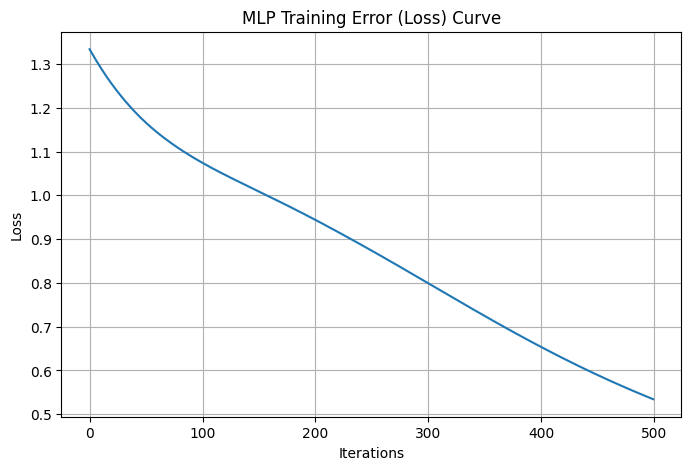

In [10]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load dataset
filepath = "/content/Iris.xlsx"
iris = pd.read_excel(filepath)

# Features and Target
X = iris.iloc[:, :-1]
y = iris.iloc[:, -1]

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# Normalize data
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# MLP Classifier
mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=500,
    random_state=42
)

# Train
mlp.fit(X_train, y_train)

# Predict
y_pred = mlp.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Error (Loss) Values
print("\nFinal Loss:", mlp.loss_)

# Plot Loss Curve
plt.figure(figsize=(8,5))
plt.plot(mlp.loss_curve_)
plt.title("MLP Training Error (Loss) Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()